# Demo of DISC tomography based on a 3D model

## Description
This notebook implements DISC based on a 3D model. 
It is designed for generating synthetic data, performing ray path matrix reconstruction, and updating velocity models through gradient-based optimization.


## Date
2026-07

In [1]:
#####Step1 import necessary package

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import lsqr
import sys
from pyekfmm import eikonal,ray2d2  #extract traveltime and ray tracing (new) functions from pyekfmm
from pyseistr.solvers import solver,conjgrad
from pyseistr.solvers import cgstep
from pyseistr.operators import adjnull,matrix_lop
from pyseistr.divne import trianglen_lop
from scipy.ndimage import gaussian_filter
import os
from pyekfmm import ray3d2,extract
from pyseistr import plot3d



In [2]:
#####Step2 create real checkboard model

nx=41;ny=41;nz=41;  ###model size 
dx=0.2;dy=0.2;dz=0.2;      ###spacing rinterval (unit km)

# coordinates of the nodes
xx = np.arange(0, (nx)*dx, dx)
yy = np.arange(0, (ny)*dx, dy)
zz = np.arange(0, (nz)*dx, dz)

#specify the anomaly
vlow=2 #(km/s)
vhig=5 #(km/s)


v=vlow*np.ones([nz,nx,ny]); #(z,x,y)

cz=np.floor((nz+1)/2).astype('int');coor_cz=zz[cz];
cx=np.floor((nx+1)/2).astype('int');coor_cx=xx[cx];
cy=np.floor((ny+1)/2).astype('int');coor_cy=yy[cy];

half = 1.0  

coor_x, coor_y, coor_z = np.meshgrid(xx, yy, zz, indexing='ij')

cube = (
    (np.abs(coor_x - coor_cx) <= half) &
    (np.abs(coor_y - coor_cy) <= half) &
    (np.abs(coor_z - coor_cz) <= half)
)

v[cube] = vhig

#########geometry setting
n_sources=30;
sources=np.concatenate([0.4*np.ones([n_sources,1]),0.4*np.ones([n_sources,1]),np.arange(0.4,n_sources*dz+0.4,dz)[:,np.newaxis]],axis=1); ######nz means n1, nx means n2 ny means n3   

n_receivers=30;
receivers=np.concatenate([7.6*np.ones([n_receivers,1]),7.6*np.ones([n_receivers,1]),np.arange(0.4,n_receivers*dz+0.4,dz)[:,np.newaxis]],axis=1); #receiver locations (nx,ny,nz)


#### model transpose for subsequent ray path matrix reconstruction
v_true = np.transpose(v, (1,2,0)); #from zxy to xyz
v_init=vlow*np.ones_like(v_true)

In [3]:
#####Step3 build ray path matrix based on eikonal wave equation
address=os.path.dirname(os.getcwd())
sys.path.insert(0, address)

from disc.raytrace import * ####import necessary functions for traveltime and ray path calculation  

###compute traveltime for each ray based on eikonal equation
traveltimes,ray_paths=compute_travel_times3D(v_true, sources, receivers, dx, dy,dz ,nx, ny,nz, 1)  


###build ray path matrix 
A=build_ray_matrix3D(ray_paths, dx, dy, dz, nx, ny, nz ,2,1)

operef=A.toarray()


obst=(np.squeeze(traveltimes))  ####observed traveltime from Eikonal equation

nd=len(obst) #####length of traveltime vector

time_eik=np.squeeze(traveltimes).reshape(n_sources,n_receivers); #traveltime estimated usig eikonal equation

time_cal=A.dot(1./v_true.reshape(nx*ny*nz,1,order='F')).reshape(n_sources,n_receivers) #### traveltime calculated using ray path matrix and true velocity model


print(np.mean((time_eik-time_cal)**2))

0.026809213780108747


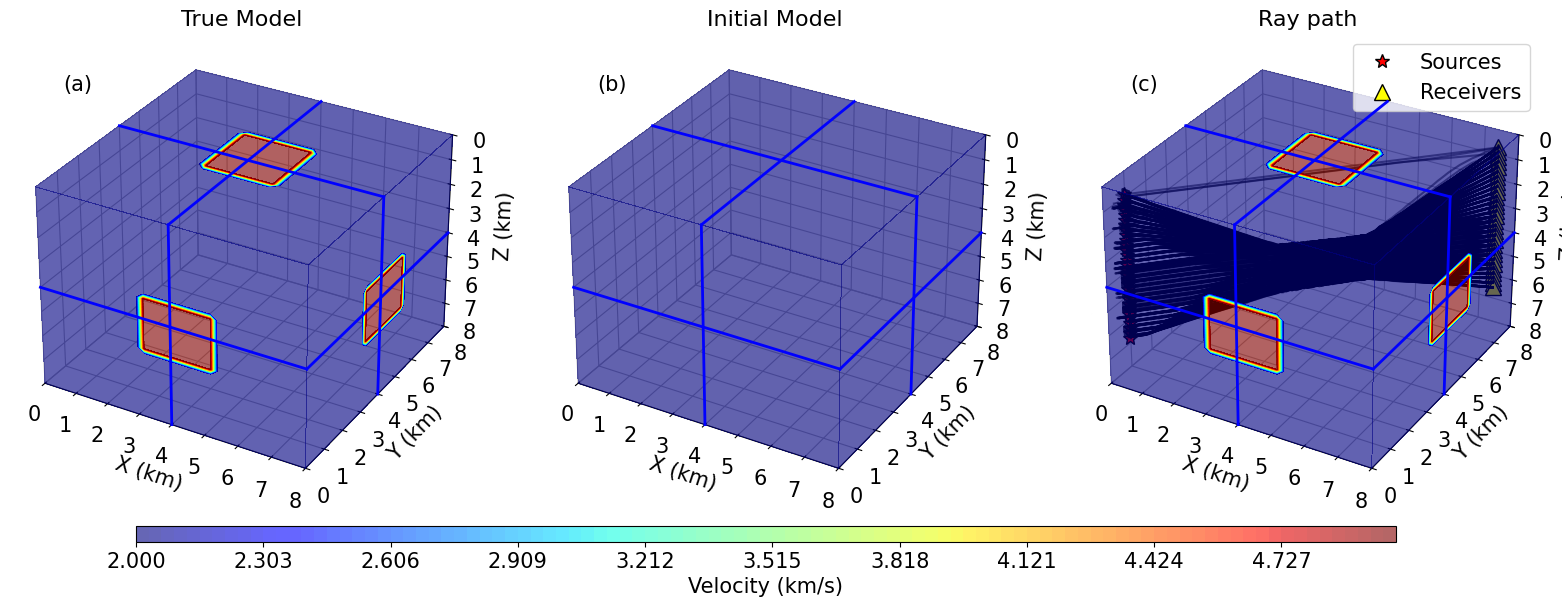

In [7]:
########Step 4 observed travel time comparison
v_low = 2
v_hig = 5


figadd=address+'/Figure/'

fig = plt.figure(figsize=(18, 8))
# --- Figure 1: v_true ---
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
plot3d(np.transpose(v_true, [2,0,1]), x=xx, y=yy, z=zz,
       cmap=plt.cm.jet,  alpha=0.6,
       ifnewfig=False, showf=False, close=False)
ax1.set_xlabel("X (km)", fontsize=15, fontweight='normal')
ax1.set_ylabel("Y (km)", fontsize=15, fontweight='normal')
ax1.set_zlabel("Z (km)", fontsize=15, fontweight='normal')
ax1.set_title("True Model", fontsize=16, fontweight='normal')
for tick in ax1.get_xticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
for tick in ax1.get_yticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
for tick in ax1.get_zticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
    
mappable = ax1.collections[0]
cax = fig.add_axes([0.12, 0.20, 0.7, 0.02])
cbar = fig.colorbar(mappable, cax=cax, orientation='horizontal')
cbar.set_label('Velocity (km/s)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')
cbar.ax.tick_params(labelsize=15)
for label in cbar.ax.get_xticklabels():  # For horizontal: get_xticklabels()
	label.set_fontweight('normal')
	label.set_fontname('DejaVu Sans')
ax1.text(1,-0,-4, '(a)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal')    
    
# --- Figure 2: v_init ---
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
plot3d(np.transpose(v_init, [2,0,1]), levels=[2,2.001], x=xx, y=yy, z=zz,
       cmap=plt.cm.jet,  alpha=0.6,
       ifnewfig=False, showf=False, close=False)
ax2.set_xlabel("X (km)", fontsize=15, fontweight='normal')
ax2.set_ylabel("Y (km)", fontsize=15, fontweight='normal')
ax2.set_zlabel("Z (km)", fontsize=15, fontweight='normal')
ax2.set_title("Initial Model", fontsize=16, fontweight='normal')
for tick in ax2.get_xticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
for tick in ax2.get_yticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
for tick in ax2.get_zticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
ax2.text(1,-0,-4, '(b)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal')    
# --- Figure 3: raypath ---
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
plot3d(np.transpose(v_true, [2,0,1]), x=xx, y=yy, z=zz,
       cmap=plt.cm.jet,  alpha=0.6,
       ifnewfig=False, showf=False, close=False)
ax3.set_xlabel("X (km)", fontsize=15, fontweight='normal')
ax3.set_ylabel("Y (km)", fontsize=15, fontweight='normal')
ax3.set_zlabel("Z (km)", fontsize=15, fontweight='normal')
ax3.set_title("Ray path", fontsize=16, fontweight='normal')
# ax3.plot(sources[:,0],sources[:,1],sources[:,2],'r^',  markersize=15)
# ax3.plot(receivers[:,0],receivers[:,1],receivers[:,2],'y*',  markersize=15)
ax3.plot(
    sources[:, 0],
    sources[:, 1],
    sources[:, 2],
    marker='*',
    linestyle='None',
    color='red',
    markeredgecolor='black',
    markersize=10,
    label='Sources'
)

ax3.plot(
    receivers[:, 0],
    receivers[:, 1],
    receivers[:, 2],
    marker='^',
    linestyle='None',
    color='yellow',
    markeredgecolor='black',
    markersize=12,
    label='Receivers'
)

ax3.legend(loc='upper right',prop={'family': 'DejaVu Sans', 'size': 15, 'weight': 'normal'})

for tick in ax3.get_xticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
for tick in ax3.get_yticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
for tick in ax3.get_zticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
for ray_x, ray_y, ray_z in ray_paths:
    ax3.plot(ray_x, ray_y, ray_z, 'k-', alpha=0.5)

ax3.text(1,-0,-4, '(c)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal')  

plt.subplots_adjust(bottom=0.21)
plt.subplots_adjust(wspace=0.15)
plt.subplots_adjust(left=0.05)
plt.show()
	

In [5]:
########Step 5 tomography inversion using DISC method in 3D case 
import time

oniter=30  ####number of outer iteration
initer=5   ####number of inner iteration
v_disc=vlow*np.ones_like(v_true)

t0 = time.perf_counter()
for i in range(oniter):
	_,ray_pathsini=compute_travel_times3D(v_disc, sources, receivers, dx, dy,dz, nx, ny, nz, 1)   ###ray traceing based on the given model
	opsr=build_ray_matrix3D(ray_pathsini, dx, dy, dz,nx, ny,nz)  ####build ray path matrix using the initial model
	nm=opsr.toarray().shape[1] 
	
	par_S={'nm':nm,'nd':nm,'nbox':[6,6,6],'ndat':[nx,ny,nz],'ndim':3}### shaping operator setting
	v_disc=tomoloop3D(v_disc,opsr,initer,nx,ny,nz,nd,obst,par_S) ### gradient estimation and model update

	v_disc = np.clip(v_disc, v_low, v_hig)

	print('iter=',i+1,np.linalg.norm(obst-np.matmul(opsr.toarray(),1./v_disc.flatten(order='F'))))

dtdisc = time.perf_counter() - t0
print('DISCt=',dtdisc) #estimated calculation time



iter= 1 28.727898735951356
iter= 2 26.954525318759327
iter= 3 25.31806684123888
iter= 4 22.97887556098729
iter= 5 22.284504909754528
iter= 6 20.018784152092177
iter= 7 19.279076010176915
iter= 8 16.94156484001834
iter= 9 16.528746751480064
iter= 10 14.92885179934816
iter= 11 14.616698521586338
iter= 12 12.849353059196332
iter= 13 12.671706111343406
iter= 14 10.975625845159447
iter= 15 10.971326324451892
iter= 16 9.797236519621551
iter= 17 9.605500841021831
iter= 18 8.308505591918319
iter= 19 8.440008143631832
iter= 20 7.563703068034113
iter= 21 7.273122925237324
iter= 22 6.494658192105164
iter= 23 6.567777598127327
iter= 24 6.0182611167005975
iter= 25 5.9022687002690954
iter= 26 5.270045474290031
iter= 27 5.656458929852732
iter= 28 4.547867597197414
iter= 29 4.88406638179181
iter= 30 4.581949694031362
DISCt= 148.96368944551796


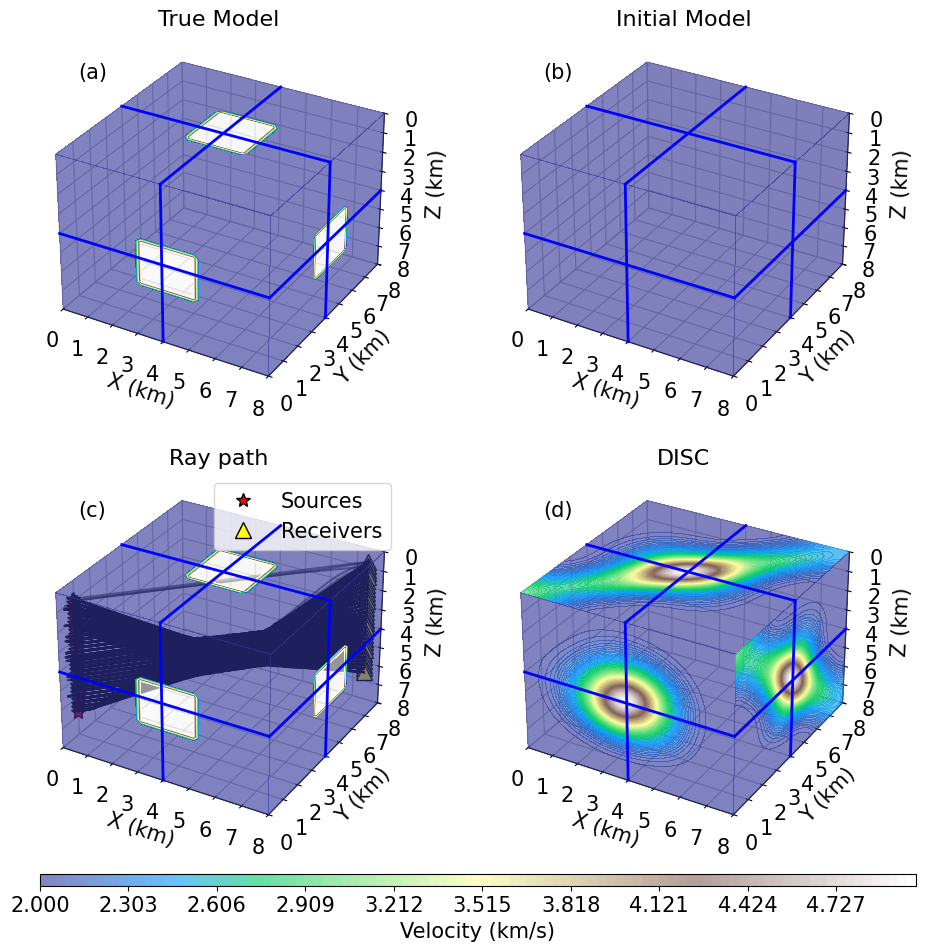

In [6]:
fig = plt.figure(figsize=(12,12))
# --- Figure 1: v_true ---
ax1 = fig.add_subplot(2,2, 1, projection='3d')
plot3d(np.transpose(v_true, [2,0,1]), x=xx, y=yy, z=zz,
       cmap=plt.cm.terrain,  alpha=0.6,
       ifnewfig=False, showf=False, close=False)
ax1.set_xlabel("X (km)", fontsize=15, fontweight='normal')
ax1.set_ylabel("Y (km)", fontsize=15, fontweight='normal')
ax1.set_zlabel("Z (km)", fontsize=15, fontweight='normal')
ax1.set_title("True Model", fontsize=16, fontweight='normal')
for tick in ax1.get_xticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
for tick in ax1.get_yticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
for tick in ax1.get_zticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
    
mappable = ax1.collections[0]
cax = fig.add_axes([0.17, 0.17, 0.73, 0.01])
cbar = fig.colorbar(mappable, cax=cax, orientation='horizontal')
cbar.set_label('Velocity (km/s)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')
cbar.ax.tick_params(labelsize=15)
for label in cbar.ax.get_xticklabels():  # For horizontal: get_xticklabels()
	label.set_fontweight('normal')
	label.set_fontname('DejaVu Sans')
ax1.text(1,-0,-4, '(a)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal')    
    
# --- Figure 2: v_init ---
ax2 = fig.add_subplot(2,2, 2, projection='3d')
plot3d(np.transpose(v_init, [2,0,1]), levels=[2,2.001], x=xx, y=yy, z=zz,
       cmap=plt.cm.terrain,  alpha=0.6,
       ifnewfig=False, showf=False, close=False)
ax2.set_xlabel("X (km)", fontsize=15, fontweight='normal')
ax2.set_ylabel("Y (km)", fontsize=15, fontweight='normal')
ax2.set_zlabel("Z (km)", fontsize=15, fontweight='normal')
ax2.set_title("Initial Model", fontsize=16, fontweight='normal')
for tick in ax2.get_xticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
for tick in ax2.get_yticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
for tick in ax2.get_zticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
ax2.text(1,-0,-4, '(b)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal')    
# --- Figure 3: raypath ---
ax3 = fig.add_subplot(2,2, 3, projection='3d')
plot3d(np.transpose(v_true, [2,0,1]), x=xx, y=yy, z=zz,
       cmap=plt.cm.terrain,  alpha=0.6,
       ifnewfig=False, showf=False, close=False)
ax3.set_xlabel("X (km)", fontsize=15, fontweight='normal')
ax3.set_ylabel("Y (km)", fontsize=15, fontweight='normal')
ax3.set_zlabel("Z (km)", fontsize=15, fontweight='normal')
ax3.set_title("Ray path", fontsize=16, fontweight='normal')
# ax3.plot(sources[:,0],sources[:,1],sources[:,2],'r^',  markersize=15)
# ax3.plot(receivers[:,0],receivers[:,1],receivers[:,2],'y*',  markersize=15)
ax3.plot(
    sources[:, 0],
    sources[:, 1],
    sources[:, 2],
    marker='*',
    linestyle='None',
    color='red',
    markeredgecolor='black',
    markersize=10,
    label='Sources'
)

ax3.plot(
    receivers[:, 0],
    receivers[:, 1],
    receivers[:, 2],
    marker='^',
    linestyle='None',
    color='yellow',
    markeredgecolor='black',
    markersize=12,
    label='Receivers'
)

ax3.legend(loc='upper right',prop={'family': 'DejaVu Sans', 'size': 15, 'weight': 'normal'})

for tick in ax3.get_xticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
for tick in ax3.get_yticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
for tick in ax3.get_zticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
for ray_x, ray_y, ray_z in ray_paths:
    ax3.plot(ray_x, ray_y, ray_z, 'k-', alpha=0.5)

ax3.text(1,-0,-4, '(c)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal')

# --- Figure 3: raypath ---
ax4 = fig.add_subplot(2, 2, 4, projection='3d')
plot3d(np.transpose(v_disc, [2,0,1]),  x=xx, y=yy, z=zz, frames=[20,20,20], ##[z,x,y]
       cmap=plt.cm.terrain,  alpha=0.6,
       ifnewfig=False, showf=False, close=False)
ax4.set_xlabel("X (km)", fontsize=15, fontweight='normal')
ax4.set_ylabel("Y (km)", fontsize=15, fontweight='normal')
ax4.set_zlabel("Z (km)", fontsize=15, fontweight='normal')
ax4.set_title("DISC", fontsize=16, fontweight='normal')
for tick in ax4.get_xticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
for tick in ax4.get_yticklabels():
    tick.set_fontweight('normal')
    tick.set_fontsize(15)
    tick.set_fontname('DejaVu Sans')
for tick in ax4.get_zticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
ax4.text(1,-0,-4, '(d)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal')     

plt.subplots_adjust(bottom=0.21)
plt.subplots_adjust(wspace=0.)
# plt.subplots_adjust(left=-3)
plt.savefig(figadd+"syn3dinv.png", dpi=300)	
plt.show()